In [1]:
%pip install -U keras opencv-python-headless==4.10.0.84

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import os

os.environ["KERAS_BACKEND"] = "torch"

import numpy as np

import matplotlib.pyplot as plt

import cv2

import torch

from keras import datasets

from torch.utils.data import DataLoader, Dataset

import torch.nn.functional as F

import torch.nn as nn



%load_ext tensorboard


In [3]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
print(f"Training set: {x_train.shape}, {y_train.shape}")
print(f"Test set: {x_test.shape}, {y_test.shape}")

Training set: (60000, 28, 28), (60000,)
Test set: (10000, 28, 28), (10000,)


In [4]:
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

In [5]:
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.dense_1 = nn.Linear(28 * 28, 128)
        self.dense_2 = nn.Linear(128, 10)
        self.dropout = nn.Dropout(0.2)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.dense_1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.dense_2(x)
        return F.log_softmax(x, dim=1)

In [6]:
model = SimpleModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for param in model.parameters():
    if param.requires_grad:
        print("param autograd:", param.shape)
        break

model.to(device)
input = torch.rand(1, 28, 28).to(device)
output = model(input)


model_parameters = filter(lambda p: p.requires_grad, model.parameters())
params = sum([np.prod(p.size()) for p in model_parameters])
print(f"Total trainable parameters: {params}")

param autograd: torch.Size([128, 784])
Total trainable parameters: 101770


In [7]:
%pip install imgaug
%pip install scikit-image --upgrade

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np



# Compatibility shim for imgaug on NumPy 2.x (np.sctypes was removed)

if not hasattr(np, "sctypes"):

    np.sctypes = {

        "int": [np.int8, np.int16, np.int32, np.int64],

        "uint": [np.uint8, np.uint16, np.uint32, np.uint64],

        "float": [np.float16, np.float32, np.float64],

        "complex": [np.complex64, np.complex128],

        "others": [np.bool_, np.object_, np.str_, np.bytes_],

    }



from imgaug import augmenters as iaa


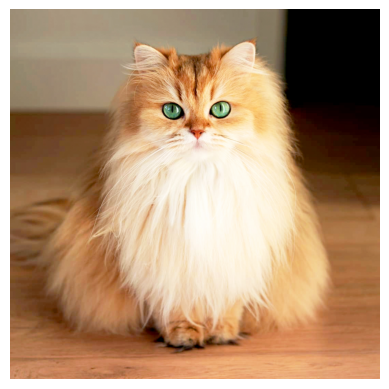

In [9]:
image = cv2.imread("cat.jpg")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

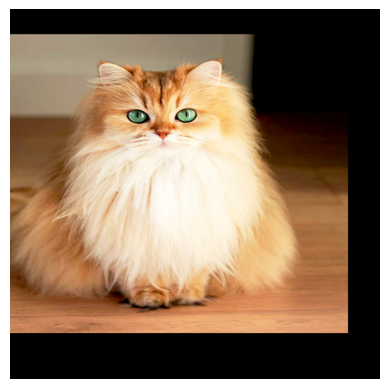

In [10]:
# Sử dụng hàm CropAndPad với tham số percent=(-0.25, 0.25)
crop_and_pad = iaa.CropAndPad(percent=(-0.25, 0.25))
cropped_and_padded_image = crop_and_pad(image=image)
plt.imshow(cv2.cvtColor(cropped_and_padded_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

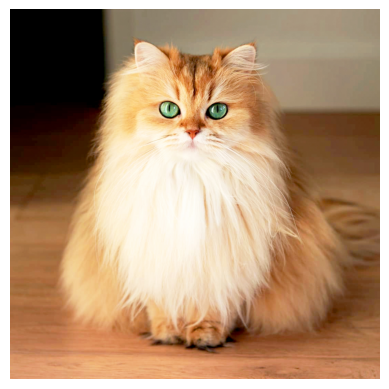

In [11]:
flip_left_right = iaa.Fliplr(1.0)
flipped_image = flip_left_right(image=image)
plt.imshow(cv2.cvtColor(flipped_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

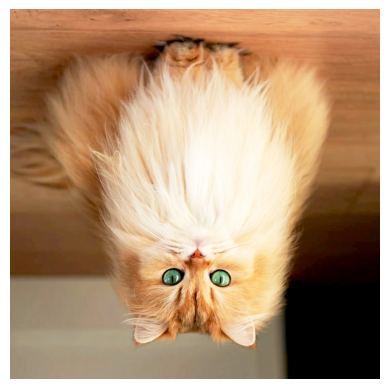

In [12]:
flip_up_down = iaa.Flipud(1.0)
flipped_ud_image = flip_up_down(image=image)
plt.imshow(cv2.cvtColor(flipped_ud_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

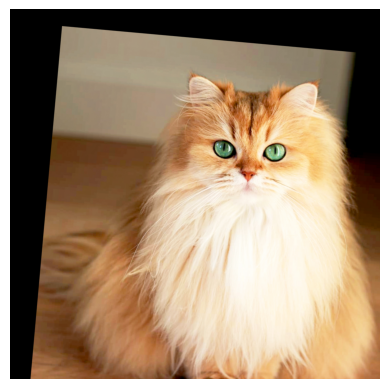

In [13]:
affine = iaa.Affine(rotate=(-15, 15), scale = (0.5, 1.5), translate_percent=(-0.2, 0.2))
import skimage._shared.utils as _skimage_shared_utils
if not hasattr(_skimage_shared_utils, '_deprecate_estimate'):
    def _deprecate_estimate(*args, **kwargs):
        pass
    _skimage_shared_utils._deprecate_estimate = _deprecate_estimate

if not hasattr(_skimage_shared_utils, "_update_from_estimate_docstring"):
    def _update_from_estimate_docstring(*args, **kwargs):
        # imgaug expects this private skimage helper in older versions
        if args and callable(args[0]) and len(args) == 1 and not kwargs:
            return args[0]
        def _decorator(func):
            return func
        return _decorator

    _skimage_shared_utils._update_from_estimate_docstring = _update_from_estimate_docstring

if not hasattr(_skimage_shared_utils, "_deprecate_inherited_estimate"):
    def _deprecate_inherited_estimate(*args, **kwargs):
        # Compatibility shim for newer scikit-image versions
        if args and callable(args[0]) and len(args) == 1 and not kwargs:
            return args[0]
        def _decorator(func):
            return func
        return _decorator

    _skimage_shared_utils._deprecate_inherited_estimate = _deprecate_inherited_estimate

if not hasattr(_skimage_shared_utils, "FailedEstimation"):
    class FailedEstimation(Exception):
        pass
    _skimage_shared_utils.FailedEstimation = FailedEstimation

affine_image = affine(image=image)
plt.imshow(cv2.cvtColor(affine_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

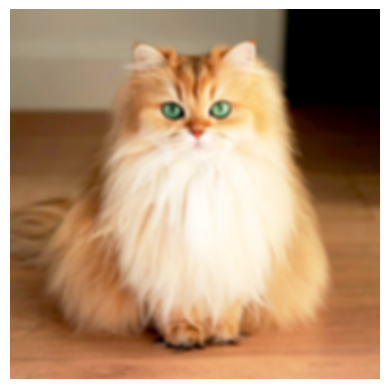

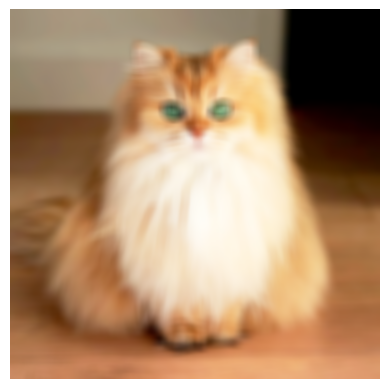

In [14]:
gaussian_blur = iaa.GaussianBlur(sigma=(5.0, 15.0))
average_blur = iaa.AverageBlur(k=(11, 31))

gaussian_blurred_image = gaussian_blur(image=image)
plt.imshow(cv2.cvtColor(gaussian_blurred_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

average_blurred_image = average_blur(image=image)
plt.imshow(cv2.cvtColor(average_blurred_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

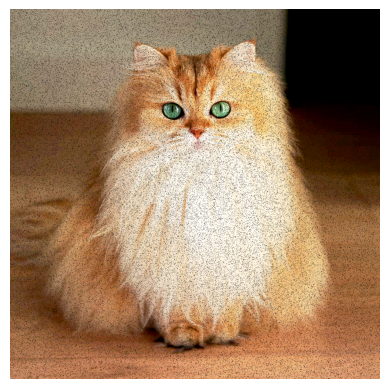

In [15]:
dropout = iaa.Dropout(p=(0, 0.2))

dropout_image = dropout(image=image)
plt.imshow(cv2.cvtColor(dropout_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

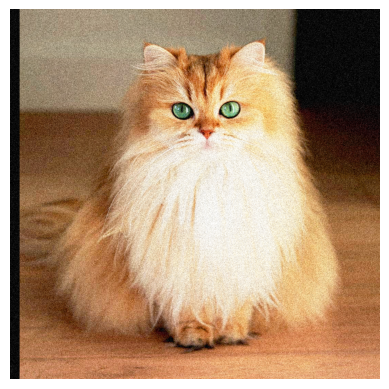

In [16]:
aug = iaa.Sequential([
    iaa.Affine(translate_px={"x": (-40, 40)}),
    iaa.AdditiveGaussianNoise(scale = 0.1 * 255)
])

plt.imshow(cv2.cvtColor(aug(image=image), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


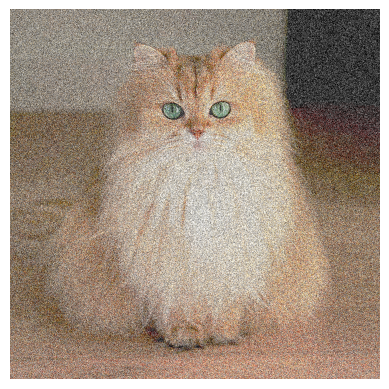

In [17]:
if not hasattr(np, 'bool'):
    np.bool = np.bool_

aug = iaa.SomeOf(2, [
    iaa.Affine(rotate=45),
    iaa.AdditiveGaussianNoise(scale=0.2*255),
    iaa.Add(50, per_channel=True),
    iaa.Sharpen(alpha=0.5)
])

plt.imshow(cv2.cvtColor(aug(image=image), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [18]:
aug = iaa.Sometimes(0.5, iaa.GaussianBlur(sigma=20.0))

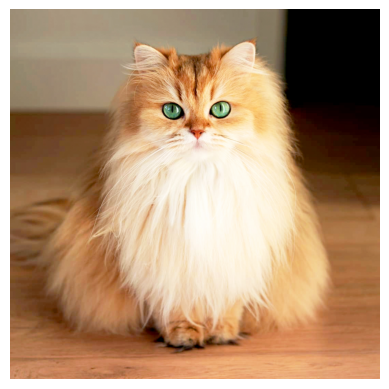

In [19]:

plt.imshow(cv2.cvtColor(aug(image=image), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [20]:
aug = iaa.Dropout(p = (0, 0.002))

In [21]:
class Generator(Dataset):
    def __init__(self, images, labels, augmenter=None):
        self.images = images
        self.labels = labels
        self.augmenter = augmenter

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.augmenter:
            image = self.augmenter(image=image)["image"]

        return torch.tensor(image, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [22]:
training_data = Generator(x_train, y_train, augmenter=aug)
train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)

In [23]:
test_data = Generator(x_test, y_test)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

torch.Size([64, 28, 28])


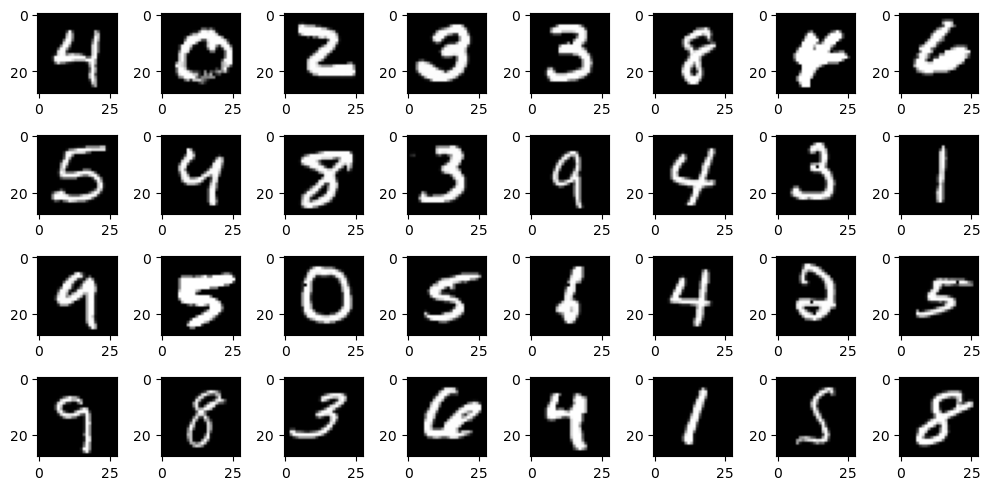

In [24]:
import tqdm
# Patch augmenter output format for current Generator implementation
if training_data.augmenter is not None:
    _base_aug = training_data.augmenter
    training_data.augmenter = lambda image, _aug=_base_aug: {"image": _aug(image=image)}

for batch_idx, target_tuple in enumerate(train_dataloader):
    images, labels = target_tuple
    print(images.shape)

    n_show = min(images.shape[0], 32)
    plt.figure(figsize=(10, 5))
    for i in range(n_show):
        plt.subplot(4, 8, i + 1)
        plt.imshow(images[i].numpy(), cmap="gray")
    plt.tight_layout()
    plt.show()
    break

In [25]:
use_cuda = torch.cuda.is_available()
optimizer = torch.optim.Adadelta(model.parameters())

if use_cuda:
    model = torch.nn.DataParallel(model)
    torch.backends.cudnn.benchmark = True

In [26]:
def train(epoch):
    model.train()
    for batch_idx, target_tuple in tqdm.tqdm(enumerate(train_dataloader), total=len(train_dataloader)):
        images, labels = target_tuple
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(images)
        loss = F.nll_loss(output, labels)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} - Loss: {loss.item():.4f}")

    global best_loss
    if best_loss is None or loss.item() < best_loss:
        best_loss = loss.item()
        torch.save(model.state_dict(), "best_model.pth")

def test(epoch):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for target_tuple in test_dataloader:
            images, labels = target_tuple
            images, labels = images.to(device), labels.to(device)
            output = model(images)
            test_loss += F.nll_loss(output, labels, reduction="sum").item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(labels.view_as(pred)).sum().item()

    test_loss /= len(test_dataloader.dataset)
    accuracy = correct / len(test_dataloader.dataset)
    print(f"Epoch {epoch} - Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.4f}")


In [27]:
epochs = 10
for epoch in range(1, epochs + 1):
    if epoch == 1 and "best_loss" not in globals():
        best_loss = None
    train(epoch)
    test(epoch)

100%|██████████| 938/938 [00:10<00:00, 91.42it/s]


Epoch 1 - Loss: 0.2639
Epoch 1 - Test Loss: 0.1398, Accuracy: 0.9585


100%|██████████| 938/938 [00:10<00:00, 92.34it/s]


Epoch 2 - Loss: 0.0326
Epoch 2 - Test Loss: 0.1041, Accuracy: 0.9692


100%|██████████| 938/938 [00:10<00:00, 91.45it/s]


...

Epoch 8 - Loss: 0.0105
Epoch 8 - Test Loss: 0.0725, Accuracy: 0.9780


100%|██████████| 938/938 [00:10<00:00, 91.93it/s]


Epoch 9 - Loss: 0.2941
Epoch 9 - Test Loss: 0.0704, Accuracy: 0.9796


100%|██████████| 938/938 [00:10<00:00, 90.19it/s]


Epoch 10 - Loss: 0.0121
Epoch 10 - Test Loss: 0.0714, Accuracy: 0.9799
